# Classification des Urgent Market Messages (REMIT/UMM)

**Objectif** : entraîner un classifieur binaire capable de distinguer un message d'**incident** (panne soudaine, force majeure, fuite…) d'un message de **maintenance planifiée** sur les infrastructures gaz européennes. Ce signal alimentera in fine un indicateur quotidien de stress utilisable par le desk trading ou les opérateurs de réseau.



## 1. Imports et chargement

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_colwidth", 200)

In [2]:
DATA_PATH = Path("..") / "data" / "raw" / "mock_remit_messages.csv"
df = pd.read_csv(DATA_PATH)
print(f"shape : {df.shape}")
print(f"label distribution : {df['label'].value_counts().to_dict()}")
display(df.head(3))
display(df.tail(3))

shape : (100, 2)
label distribution : {0: 50, 1: 50}


,message,label
0,Planned annual maintenance of the Nord Stream pipeline section. Capacity reduced by 40 Mcm/d from Oct 10 to Oct 20.,0
1,Scheduled inspection of the LNG terminal storage tank at Rotterdam. Minor impact on regasification.,0
2,"Routine integrity check at GASCADE pipeline IP Mallnow. Reduced firm capacity 12 Mcm/d, 14:00 CET 03/04 to 06:00 CET 05/04.",0


,message,label
97,"Lightning-induced trip at Eustream dispatch centre, backup systems engaged, brief data loss.",1
98,"Valve failure on inlet manifold at Reden storage, withdrawal stopped pending repair.",1
99,Interruption of flows at IP Mosonmagyarovar following control system alarm.,1


## 2. EDA rapide

On vérifie que les deux classes ont des longueurs comparables (pour qu'on ne puisse pas trivialement classifier par "nombre de mots") et on jette un œil au vocabulaire.

In [3]:
df["n_chars"] = df["message"].str.len()
df["n_words"] = df["message"].str.split().str.len()

print(df.groupby("label")[["n_chars", "n_words"]].agg(["mean", "median", "min", "max"]).round(1))

      n_chars                 n_words               
         mean median min  max    mean median min max
label                                               
0       108.1  107.0  83  127    15.7   16.0  11  20
1        84.8   84.0  64  129    12.1   12.0   9  19


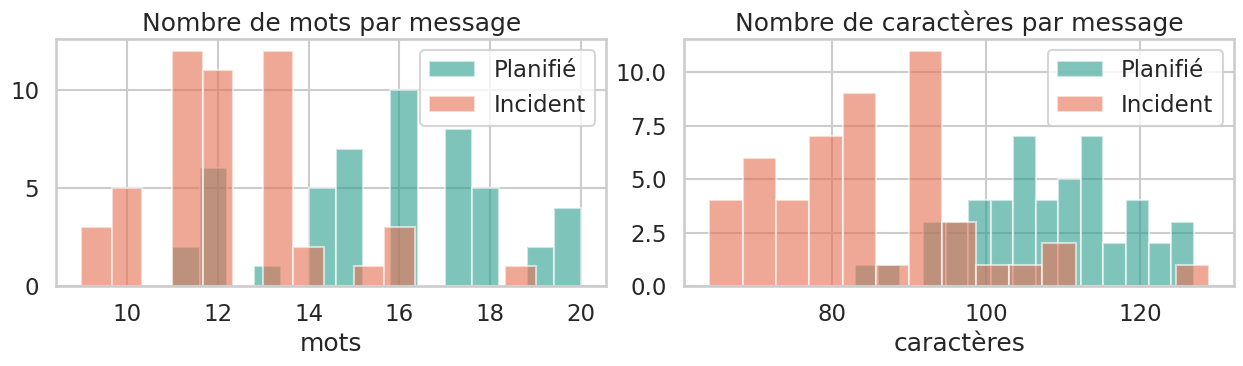

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color, name in [(0, "#2a9d8f", "Planifié"), (1, "#e76f51", "Incident")]:
    sub = df[df.label == label]
    axes[0].hist(sub["n_words"], bins=15, alpha=0.6, color=color, label=name, edgecolor="white")
    axes[1].hist(sub["n_chars"], bins=15, alpha=0.6, color=color, label=name, edgecolor="white")

axes[0].set_title("Nombre de mots par message")
axes[0].set_xlabel("mots")
axes[0].legend()
axes[1].set_title("Nombre de caractères par message")
axes[1].set_xlabel("caractères")
axes[1].legend()

plt.tight_layout()
plt.show()

Les distributions se recouvrent largement : on ne pourra pas classifier sur la simple longueur du message. Le signal devra venir du vocabulaire.

## 3. Preprocessing du texte

Nettoyage minimaliste :
**lowercase**, **suppression des chiffres**, **suppression de la ponctuation**, **pas de stop-word removal**.
On garde le texte original sous `message`, et on stocke la version nettoyée sous `clean`.

In [5]:
def clean_text(text: str) -> str:
    text = text.lower()
    # remplace tout ce qui n'est pas une lettre par un espace
    text = re.sub(r"[^a-z]+", " ", text)
    # collapse multi-espaces
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean"] = df["message"].apply(clean_text)

# vérification rapide
df[["message", "clean"]].sample(4, random_state=RANDOM_STATE)

,message,clean
83,"Compressor train E-2 ejected after over-speed event, operations team on site.",compressor train e ejected after over speed event operations team on site
53,Suspected gas leak reported on the Forties Pipeline System. Flows curtailed pending diagnostic.,suspected gas leak reported on the forties pipeline system flows curtailed pending diagnostic
70,"Spurious high-temperature trip on compressor C-7 at GASCADE Reckrod, cause not yet identified.",spurious high temperature trip on compressor c at gascade reckrod cause not yet identified
45,Planned change of pig launcher seals at Greifswald. Capacity briefly reduced by 5 Mcm/d on 19/08.,planned change of pig launcher seals at greifswald capacity briefly reduced by mcm d on


In [6]:
df.to_csv('../data/clean/clean_mock_messages.csv')

## 4. Train / test split

Split stratifié 80 / 20 → 80 messages d'entraînement, 20 de test (10 planifiés + 10 incidents). On fixe `random_state=42` pour la reproductibilité.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean"],
    df["label"],
    test_size=0.20,
    stratify=df["label"],
    random_state=RANDOM_STATE,
)

print(f"train : {len(X_train)} messages  |  test : {len(X_test)} messages")
print(f"train labels : {y_train.value_counts().to_dict()}")
print(f"test  labels : {y_test.value_counts().to_dict()}")

train : 80 messages  |  test : 20 messages
train labels : {0: 40, 1: 40}
test  labels : {1: 10, 0: 10}


## 5. Pipeline scikit-learn

On encapsule le `TfidfVectorizer` et la `LogisticRegression` dans un `Pipeline`. Avantages :
- on entraîne et on évalue en un seul `fit` / `predict` ;
- le pipeline complet est sérialisable (utile en production) ;
- la fonction `classify_messages` en fin de notebook peut être appelée sur du texte brut sans avoir à re-vectoriser à la main.

Hyperparamètres :

| Paramètre | Valeur | Justification |
|---|---|---|
| `ngram_range` | `(1, 2)` | Capter "force majeure", "until further", "as planned"… |
| `min_df` | `2` | Ignorer les tokens qui n'apparaissent que dans un message |
| `stop_words` | `None` | Consigne projet |
| `C` (LogReg) | `1.0` | Régularisation L2 par défaut, suffisant ici |


In [8]:
pipe = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                stop_words=None,
                lowercase=True,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                C=1.0,
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

pipe.fit(X_train, y_train)

vocab_size = len(pipe.named_steps["tfidf"].vocabulary_)
print(f"vocabulaire TF-IDF : {vocab_size} tokens (1-grammes + bigrammes)")

vocabulaire TF-IDF : 256 tokens (1-grammes + bigrammes)


In [9]:
pipe

Pipeline(steps=[('tfidf', TfidfVectorizer(min_df=2, ngram_range=(1, 2))),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

## 6. Évaluation sur le set de test

In [10]:
y_pred = pipe.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=["Planifié (0)", "Incident (1)"]))

Accuracy : 80.00%

              precision    recall  f1-score   support

Planifié (0)       0.75      0.90      0.82        10
Incident (1)       0.88      0.70      0.78        10

    accuracy                           0.80        20
   macro avg       0.81      0.80      0.80        20
weighted avg       0.81      0.80      0.80        20



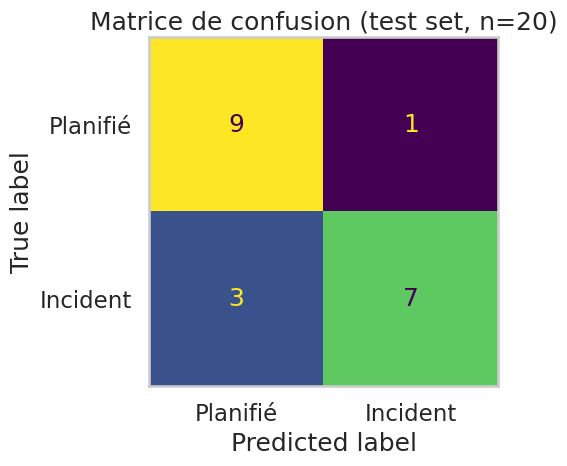

In [11]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Planifié", "Incident"])
disp.plot(ax=ax, colorbar=False, values_format="d")
ax.set_title("Matrice de confusion (test set, n=20)")
ax.grid(False)
plt.tight_layout()
plt.show()

### Analyse des erreurs

S'il y a des erreurs, on les inspecte une par une : ce sont les cas-pièges du dataset (cf. `rapport_nlp.md` section "Construction du dataset").

In [12]:
errors = pd.DataFrame(
    {
        "message": X_test.values,
        "true": y_test.values,
        "pred": y_pred,
        "proba_incident": pipe.predict_proba(X_test)[:, 1].round(3),
    }
)
errors = errors[errors["true"] != errors["pred"]]
if len(errors) == 0:
    print("Aucune erreur sur le test set.")
else:
    print(f"{len(errors)} erreur(s) :")
    display(errors)

4 erreur(s) :

,message,true,pred,proba_incident
0,pipeline rupture detected between kp and kp section isolated repair team mobilised,1,0,0.449
9,routine scada upgrade at snam rete dispatching centre minor signal handling impact contingency procedures in place,0,1,0.506
11,trip of regasification pump p at dunkerque lng send out reduced by gwh h no etr yet,1,0,0.391
19,pipeline integrity alarm raised on segment kp section depressurised as precaution,1,0,0.483


## 7. Feature importance — les mots-clés les plus prédictifs

Pour une `LogisticRegression` binaire avec classe positive = 1 (incident) :
- coefficient **positif** → le token pousse vers **incident** (rouge),
- coefficient **négatif** → le token pousse vers **planifié** (vert).

On affiche les 15 plus discriminants dans chaque direction.

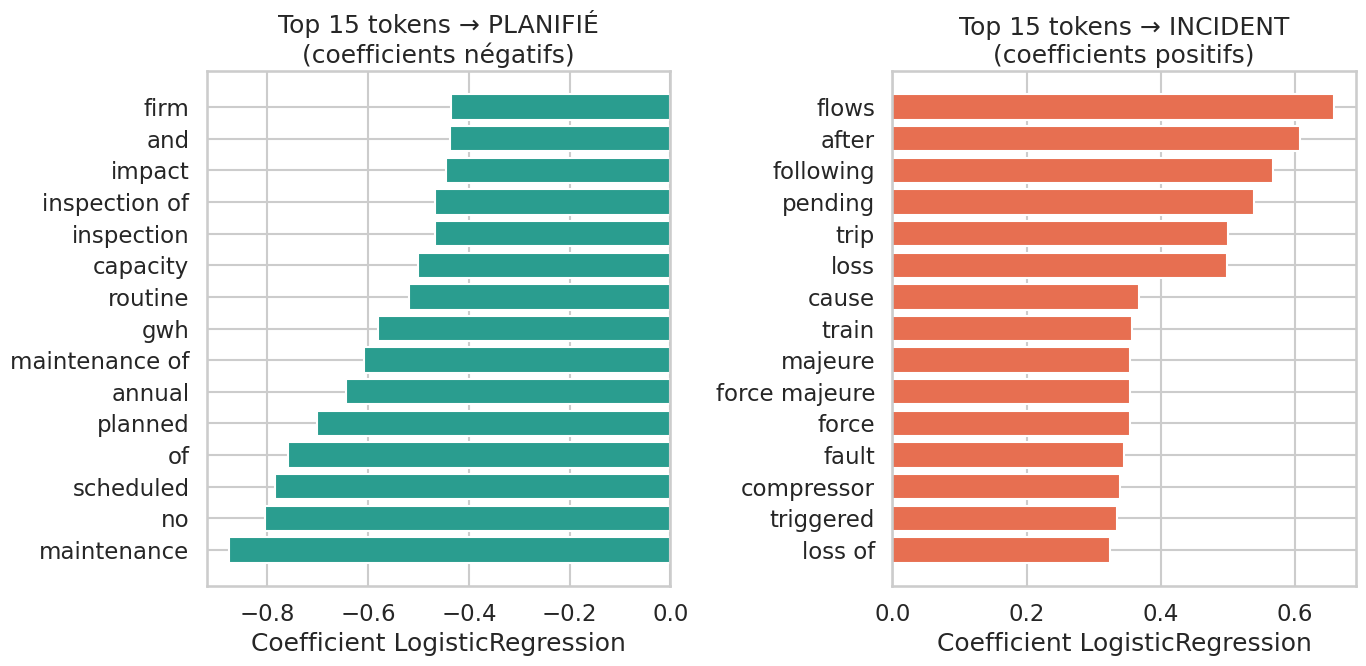

In [13]:
vectorizer = pipe.named_steps["tfidf"]
clf = pipe.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = clf.coef_[0]

importance = pd.DataFrame({"token": feature_names, "coef": coefs})

top_incident = importance.nlargest(15, "coef").sort_values("coef")
top_planned = importance.nsmallest(15, "coef").sort_values("coef")

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=False)

axes[0].barh(top_planned["token"], top_planned["coef"], color="#2a9d8f")
axes[0].set_title("Top 15 tokens → PLANIFIÉ\n(coefficients négatifs)")
axes[0].set_xlabel("Coefficient LogisticRegression")
axes[0].axvline(0, color="black", linewidth=0.8)

axes[1].barh(top_incident["token"], top_incident["coef"], color="#e76f51")
axes[1].set_title("Top 15 tokens → INCIDENT\n(coefficients positifs)")
axes[1].set_xlabel("Coefficient LogisticRegression")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

- **Côté planifié** (vert) : on s'attend à voir `annual`, `scheduled`, `planned`, `maintenance`, `routine`, `inspection`, `overhaul`, `pre-winter`, des bigrammes du type `as part`, `from to`, `working days`.
- **Côté incident** (rouge) : on s'attend à voir `trip`, `fault`, `failure`, `leak`, `fire`, `alarm`, `anomaly`, `force majeure`, `etr`, `sudden`, `cause`, `malfunction`, `lightning`.

On voit des tokens 'non métier' (noms d'actifs spécifiques, articles, etc.) dans les 15, on peut interpréter cela comme un signe que le corpus est trop petit pour stabiliser le ranking, et que la V2 (corpus réel élargi) est nécessaire.

In [14]:
# Tableau récapitulatif pour exporter / discuter avec le desk
top_table = pd.concat(
    [
        top_incident.assign(direction="→ INCIDENT").sort_values("coef", ascending=False),
        top_planned.assign(direction="→ PLANIFIÉ").sort_values("coef"),
    ]
).reset_index(drop=True)
top_table

,token,coef,direction
0,flows,0.657668,→ INCIDENT
1,after,0.606577,→ INCIDENT
2,following,0.566884,→ INCIDENT
3,pending,0.538258,→ INCIDENT
4,trip,0.499865,→ INCIDENT
5,loss,0.497819,→ INCIDENT
6,cause,0.367166,→ INCIDENT
7,train,0.357392,→ INCIDENT
8,force,0.353456,→ INCIDENT
9,force majeure,0.353456,→ INCIDENT


## 8. Test en conditions réelles — fonction interactive

On expose maintenant une fonction `classify_messages(texts)` qui prend une liste de chaînes brutes (telles que copiées depuis un site de TSO) et renvoie un `DataFrame` avec la prédiction et la probabilité.


In [15]:
def classify_messages(texts: list[str]) -> pd.DataFrame:
    """Classifie une liste de messages REMIT/UMM bruts.

    Parameters
    ----------
    texts : list[str]
        Messages tels que copiés depuis EEX, GRTgaz, ENTSOG, Gassco, etc.
        Le preprocessing (lowercase, strip ponctuation/chiffres) est appliqué
        automatiquement par le pipeline.

    Returns
    -------
    pd.DataFrame avec les colonnes :
        - message_excerpt : début du message (80 premiers caractères)
        - prediction     : "Planifié" ou "Incident"
        - proba_incident : probabilité estimée par le modèle (0 à 1)
        - confidence     : "haute" si proba > 0.85 ou < 0.15, sinon "moyenne"
    """
    if not texts:
        return pd.DataFrame(columns=["message_excerpt", "prediction", "proba_incident", "confidence"])

    cleaned = [clean_text(t) for t in texts]
    probas = pipe.predict_proba(cleaned)[:, 1]
    preds = (probas >= 0.5).astype(int)

    def _conf(p: float) -> str:
        return "haute" if (p > 0.85 or p < 0.15) else "moyenne"

    return pd.DataFrame(
        {
            "message": [t[:80] + ("…" if len(t) > 80 else "") for t in texts],
            "prediction": ["Incident" if p == 1 else "Planifié" for p in preds],
            "proba_incident": probas.round(3),
            "confidence": [_conf(p) for p in probas],
        }
    )

### Smoke test sur deux exemples bidon

In [16]:
smoke_examples = [
    "Annual planned maintenance of the IP Bocholtz metering skid. Capacity reduced 5 GWh/h from 12/03 to 14/03.",
    "Trip of compressor unit at Mallnow following sudden vibration alarm. Cause under investigation.",
]
classify_messages(smoke_examples)

,message,prediction,proba_incident,confidence
0,Annual planned maintenance of the IP Bocholtz metering skid. Capacity reduced 5 …,Planifié,0.226,moyenne
1,Trip of compressor unit at Mallnow following sudden vibration alarm. Cause under…,Incident,0.701,moyenne


### Test sur des messages "réels" à coller ici

Remplacer le contenu de la liste `real_world_messages` ci-dessous par des messages **copiés depuis EEX / GRTgaz / ENTSOG / Gassco**. Les trois messages ci-dessous sont des exemples plausibles dans le style des vrais UMM ; ils servent juste à montrer que la fonction tourne. À remplacer en démo live.

In [17]:
# ⚠️ Vrais messages copiés depuis EEX/GRTgaz/ENTSOG.
real_world_messages = [
    # "vrai EEX" — interruption non planifiée
    "Due to an unforeseen technical issue at the Drozdovichi metering station, "
    "physical flows have been interrupted since 06:00 CET. Restoration time is "
    "currently unknown and shippers will be informed as soon as more information "
    "is available.",
    # "vrai GRTgaz" — maintenance programmée
    "Maintenance works scheduled on the Taisnières H interconnection point from "
    "02/04/2026 06:00 to 04/04/2026 22:00. Firm capacity will be reduced by "
    "120 GWh/h during the operation. Shippers are kindly invited to adapt "
    "their nominations accordingly.",
    # "vrai Gassco" — ambigu : commence par une description calme
    "Following the detection of moisture in the export gas stream at Kollsnes, "
    "treatment train T-3 has been isolated for purge. Estimated time of "
    "restoration: 18 hours.",
]

classify_messages(real_world_messages)

,message,prediction,proba_incident,confidence
0,"Due to an unforeseen technical issue at the Drozdovichi metering station, physic…",Incident,0.561,moyenne
1,Maintenance works scheduled on the Taisnières H interconnection point from 02/04…,Planifié,0.217,moyenne
2,"Following the detection of moisture in the export gas stream at Kollsnes, treatm…",Incident,0.591,moyenne


# 9. Pipeline NLP avec fonctions packagés

In [36]:
from gas_intelligence.nlp.preprocessing import clean_text, load_remit_dataset
from gas_intelligence.nlp.model import (
    train_classifier,
    evaluate_classifier,
    extract_feature_importance,
)
from gas_intelligence.nlp.inference import classify_messages
from sklearn.model_selection import train_test_split

df_pkg = load_remit_dataset()
X_pkg = df_pkg["message"].apply(clean_text)
X_train_pkg, X_test_pkg, y_train_pkg, y_test_pkg = train_test_split(
    X_pkg, df_pkg["label"], test_size=0.20, stratify=df_pkg["label"], random_state=42,
)
pipe_pkg = train_classifier(X_train_pkg, y_train_pkg)
results_pkg = evaluate_classifier(pipe_pkg, X_test_pkg, y_test_pkg)
features_pkg = extract_feature_importance(pipe_pkg, top_n=5)
predictions_pkg = classify_messages(pipe_pkg, [
    "Trip of compressor unit at Mallnow following sudden alarm, ETR pending.",
    "Annual planned maintenance of OPAL pipeline from 12 to 18 September.",
])

predictions_pkg

,message_excerpt,prediction,proba_incident,confidence
0,"Trip of compressor unit at Mallnow following sudden alarm, ETR pending.",Incident,0.719,moyenne
1,Annual planned maintenance of OPAL pipeline from 12 to 18 September.,Planifié,0.213,moyenne
